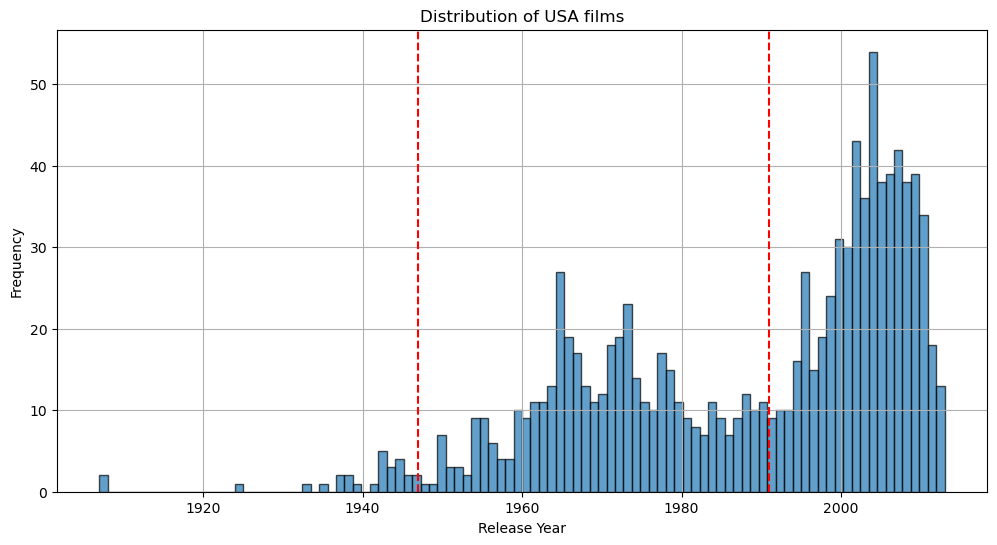

The country with the most movie releases is: {"/m/09c7w0": "United States of America"} with 29156 movies.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the TSV file into a DataFrame
file_path = '../data/movie.metadata.tsv'  # Replace with your actual file path
df = pd.read_csv(file_path, sep='\t', header=None)

# Extract the release date (year) from the 4th column
clean_df['release_year'] = df[3].str[:4]

# Drop rows where release_year is NaN (empty values)
df = df.dropna(subset=['release_year'])

# Convert release_year to integer
df['release_year'] = df['release_year'].astype(int)

# Drop movies released before 1900
df = df[df['release_year'] >= 1900]

# Extract the country column
df['country'] = df[7]

# Count the number of movies per country
country_counts = df['country'].value_counts()

# Find the country with the most movie releases
top_country = country_counts.idxmax()
top_country_count = country_counts.max()

# country = 'United States of America'
# country = 'Russia'
country = 'Spain'

usa = df[df['country'].str.contains(country, na=False)]

plt.figure(figsize=(12,6))
plt.hist(usa['release_year'], bins=100, edgecolor='black', alpha=0.7)
plt.title(f'Distribution of USA films')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
# draw red on the cold war period
plt.axvline(x=1947, color='red', linestyle='--')
plt.axvline(x=1991, color='red', linestyle='--')
plt.grid(True)
plt.show()

# # Get important countries with significant movie counts (e.g., more than 100 movies)
# important_countries = country_counts[country_counts > 100]

# # Plot the distribution for the top country
# top_country_movies = df[df['country'].str.contains(top_country, na=False)]

# plt.figure(figsize=(12,6))
# plt.hist(top_country_movies['release_year'], bins=100, edgecolor='black', alpha=0.7)
# plt.title(f'Distribution of Movie Release Years ({top_country})')
# plt.xlabel('Release Year')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

# Plot the distribution of release years for other important countries
# for country in important_countries.index:
#     country_movies = df[df['country'].str.contains(country, na=False)]
#     plt.figure(figsize=(12,6))
#     plt.hist(country_movies['release_year'], bins=100, edgecolor='black', alpha=0.7, label=country)
#     plt.title(f'Distribution of Movie Release Years ({country})')
#     plt.xlabel('Release Year')
#     plt.ylabel('Frequency')
#     plt.grid(True)
#     plt.show()

# Output the country with the most movie releases
print(f"The country with the most movie releases is: {top_country} with {top_country_count} movies.")

In [2]:
# extract plot summaries 
plots_df = pd.read_csv('../data/plot_summaries.txt', sep='\t', header=None)
plots_df.columns = ['movie_id', 'plot']
first_summary = plots_df['plot'][0]
plots_df.head()


,movie_id,plot
0,23890098,"Shlykov, a hard-working taxi driver and Lyosha..."
1,31186339,The nation of Panem consists of a wealthy Capi...
2,20663735,Poovalli Induchoodan is sentenced for six yea...
3,2231378,"The Lemon Drop Kid , a New York City swindler,..."
4,595909,Seventh-day Adventist Church pastor Michael Ch...


In [ ]:

# Merge the two dataframes
merged_df = pd.merge(df, plots_df, left_on='wiki_movie_id', right_on='movie_id')

ValueError: Length mismatch: Expected axis has 11 elements, new values have 9 elements

In [7]:
import spacy
from textblob import TextBlob

# Load SpaCy model for NER and dependency parsing
nlp = spacy.load("en_core_web_sm")

# Movie plot summary to analyze
first_summary = "During World War II, the Allies face the Axis powers in a brutal conflict. The Allies, depicted as courageous and resilient, fight against tyranny, while the Axis is portrayed as ruthless and oppressive."

# Custom list of known belligerents for historical contexts
known_belligerents = ["Allies", "Axis"]

# Dictionary to store portrayals
belligerents = {key: {"descriptions": [], "sentiment": 0} for key in known_belligerents}

# Process the text
doc = nlp(first_summary)

# Analyze sentences for descriptions and sentiment
for sent in doc.sents:
    for belligerent in known_belligerents:
        if belligerent in sent.text:
            # Sentiment analysis
            blob = TextBlob(sent.text)
            belligerents[belligerent]["sentiment"] += blob.sentiment.polarity
            
            # Extract descriptive words related to the belligerent
            for token in sent:
                if token.dep_ in ["amod", "acomp", "attr"]:
                    belligerents[belligerent]["descriptions"].append(token.text)

# Display results
for belligerent, info in belligerents.items():
    descriptions = ", ".join(info["descriptions"])
    sentiment = "Positive" if info["sentiment"] > 0 else "Negative" if info["sentiment"] < 0 else "Neutral"
    print(f"{belligerent} portrayal:\n- Descriptions: {descriptions}\n- Sentiment: {sentiment}")

Allies portrayal:
- Descriptions: brutal, courageous, ruthless
- Sentiment: Negative
Axis portrayal:
- Descriptions: brutal, courageous, ruthless
- Sentiment: Negative
